<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/GVH_Coupled_Hierarchy_Test_0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GVH Coupled Hierarchy Test 0.1

## 1. Objectif

Ce notebook teste une transition conceptuelle du programme GVH :

\[
\boxed{
\text{hiérarchie de trajectoires superposées}
\;\longrightarrow\;
\text{hiérarchie de dynamiques couplées}
}
\]

Le test tri-niveau additif précédent considérait une construction de type :

\[
X(t)
=
X_M(t)
+
\lambda_-(t)X_L(t)
+
\lambda_+(t)X_U(t).
\]

Cette construction était additive au niveau générateur. Une non-additivité observée après application d'une observable non linéaire telle que

\[
D_T[X]=\|\Delta X\|
\]

ne pouvait donc pas être interprétée, à elle seule, comme une interaction dynamique entre niveaux.

Le présent notebook introduit trois niveaux dynamiques :

\[
L \leftrightarrow M \leftrightarrow U,
\]

où :

- \(L\) désigne le niveau inférieur ;
- \(M\) désigne le niveau central ;
- \(U\) désigne le niveau supérieur.

Aucune interaction directe \(L \leftrightarrow U\) n'est introduite dans le modèle minimal.

Le système candidat est :

\[
\dot X_L
=
f_L(X_L)
+
\alpha(X_M-X_L),
\]

\[
\dot X_M
=
f_M(X_M)
+
\beta(X_L-X_M)
+
\gamma(X_U-X_M),
\]

\[
\dot X_U
=
f_U(X_U)
+
\delta(X_M-X_U).
\]

Les termes de voisinage modifient directement les équations du mouvement. Le modèle n'est donc plus une simple superposition de trajectoires préexistantes.

## Hypothèse testée

L'hypothèse exploratoire est qu'une dynamique locale de voisinage

\[
L \leftrightarrow M \leftrightarrow U
\]

peut produire une organisation géométrique distinguable :

1. du système totalement découplé ;
2. de l'ablation du lien inférieur ;
3. de l'ablation du lien supérieur ;
4. d'un null qui détruit spécifiquement l'organisation du couplage tout en préservant autant que possible les dynamiques marginales.

## Discipline méthodologique

Les cas d'ablation, paramètres de départ, métriques principales et nulls seront définis avant l'inspection des résultats confirmatoires.

Un écart descriptif entre trajectoires ne sera pas interprété comme une preuve de couplage.

Une non-additivité apparaissant uniquement après application de \(D_T\), \(S_T\), \(R_{\rm super}\) ou d'une autre observable non linéaire ne constituera pas, à elle seule, une preuve d'interaction dynamique.

In [3]:
# ============================================================
# 2. Définition préspécifiée des dynamiques intrinsèques
#    et des paramètres de couplage
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 2.1 Paramètres numériques figés avant simulation
# ------------------------------------------------------------

N = 5000

t_min = 0.0
t_max = 40.0 * np.pi

t_eval = np.linspace(t_min, t_max, N)


# ------------------------------------------------------------
# 2.2 Fréquences intrinsèques des trois niveaux
#
# Convention :
# L = niveau inférieur, rapide
# M = niveau central, intermédiaire
# U = niveau supérieur, lent
# ------------------------------------------------------------

omega_L = 1.00
omega_M = 0.20
omega_U = 0.03


# ------------------------------------------------------------
# 2.3 Paramètres de couplage diffusif
#
# alpha : M -> L
# beta  : L -> M
# gamma : U -> M
# delta : M -> U
#
# Valeurs modérées, figées avant inspection des résultats
# ------------------------------------------------------------

alpha = 0.04
beta  = 0.06
gamma = 0.06
delta = 0.04


# ------------------------------------------------------------
# 2.4 Conditions initiales
#
# États 2D :
# X_L = (x_L, y_L)
# X_M = (x_M, y_M)
# X_U = (x_U, y_U)
#
# Phases initiales distinctes et figées
# ------------------------------------------------------------

phi_L0 = 0.00
phi_M0 = np.pi / 3.0
phi_U0 = 2.0 * np.pi / 3.0

X_L0 = np.array([
    np.cos(phi_L0),
    np.sin(phi_L0)
])

X_M0 = np.array([
    np.cos(phi_M0),
    np.sin(phi_M0)
])

X_U0 = np.array([
    np.cos(phi_U0),
    np.sin(phi_U0)
])

Y0 = np.concatenate([
    X_L0,
    X_M0,
    X_U0
])


# ------------------------------------------------------------
# 2.5 Dynamiques intrinsèques
#
# Rotation harmonique 2D :
#
# dx/dt = -omega * y
# dy/dt =  omega * x
# ------------------------------------------------------------

def f_rot(X, omega):
    """
    Dynamique intrinsèque d'un oscillateur 2D harmonique.
    """
    x, y = X

    return np.array([
        -omega * y,
         omega * x
    ])


def f_L(X_L):
    return f_rot(X_L, omega_L)


def f_M(X_M):
    return f_rot(X_M, omega_M)


def f_U(X_U):
    return f_rot(X_U, omega_U)


# ------------------------------------------------------------
# 2.6 Vérifications avant simulation
# ------------------------------------------------------------

print("Paramètres préspécifiés du système couplé")
print("=" * 72)

print("\nGrille temporelle :")
print(f"N       = {N}")
print(f"t_min   = {t_min:.6f}")
print(f"t_max   = {t_max:.6f}")

print("\nFréquences intrinsèques :")
print(f"omega_L = {omega_L:.6f}")
print(f"omega_M = {omega_M:.6f}")
print(f"omega_U = {omega_U:.6f}")

print("\nCouplages diffusifs :")
print(f"alpha   = {alpha:.6f}   # M -> L")
print(f"beta    = {beta:.6f}   # L -> M")
print(f"gamma   = {gamma:.6f}   # U -> M")
print(f"delta   = {delta:.6f}   # M -> U")

print("\nPhases initiales :")
print(f"phi_L0  = {phi_L0:.12f}")
print(f"phi_M0  = {phi_M0:.12f}")
print(f"phi_U0  = {phi_U0:.12f}")

print("\nÉtat initial concaténé :")
print(f"Y0      = {Y0}")
print(f"shape   = {Y0.shape}")

Paramètres préspécifiés du système couplé

Grille temporelle :
N       = 5000
t_min   = 0.000000
t_max   = 125.663706

Fréquences intrinsèques :
omega_L = 1.000000
omega_M = 0.200000
omega_U = 0.030000

Couplages diffusifs :
alpha   = 0.040000   # M -> L
beta    = 0.060000   # L -> M
gamma   = 0.060000   # U -> M
delta   = 0.040000   # M -> U

Phases initiales :
phi_L0  = 0.000000000000
phi_M0  = 1.047197551197
phi_U0  = 2.094395102393

État initial concaténé :
Y0      = [ 1.         0.         0.5        0.8660254 -0.5        0.8660254]
shape   = (6,)


In [4]:
# ============================================================
# 3. Fonction génératrice unique des quatre cas dynamiques
# ============================================================

VALID_CASES = (
    "FULL",
    "NO_LOWER",
    "NO_UPPER",
    "DECOUPLED",
)


def coupled_hierarchy_rhs(t, Y, case="FULL"):
    """
    Système tri-niveau 2D à couplage diffusif entre voisins.

    État :
        Y = [x_L, y_L, x_M, y_M, x_U, y_U]

    Cas :
        FULL
            L <-> M <-> U

        NO_LOWER
            suppression complète du lien L <-> M
            maintien du lien M <-> U

        NO_UPPER
            maintien du lien L <-> M
            suppression complète du lien M <-> U

        DECOUPLED
            aucun couplage entre niveaux
    """

    if case not in VALID_CASES:
        raise ValueError(
            f"case doit appartenir à {VALID_CASES}, reçu : {case}"
        )

    # --------------------------------------------------------
    # Décomposition de l'état
    # --------------------------------------------------------

    X_L = np.asarray(Y[0:2], dtype=float)
    X_M = np.asarray(Y[2:4], dtype=float)
    X_U = np.asarray(Y[4:6], dtype=float)


    # --------------------------------------------------------
    # Dynamiques intrinsèques
    # --------------------------------------------------------

    dX_L = f_L(X_L)
    dX_M = f_M(X_M)
    dX_U = f_U(X_U)


    # --------------------------------------------------------
    # Activation préspécifiée des liens
    # --------------------------------------------------------

    lower_link_active = case in (
        "FULL",
        "NO_UPPER",
    )

    upper_link_active = case in (
        "FULL",
        "NO_LOWER",
    )


    # --------------------------------------------------------
    # Lien inférieur bidirectionnel : L <-> M
    # --------------------------------------------------------

    if lower_link_active:

        # M -> L
        dX_L = dX_L + alpha * (X_M - X_L)

        # L -> M
        dX_M = dX_M + beta * (X_L - X_M)


    # --------------------------------------------------------
    # Lien supérieur bidirectionnel : M <-> U
    # --------------------------------------------------------

    if upper_link_active:

        # U -> M
        dX_M = dX_M + gamma * (X_U - X_M)

        # M -> U
        dX_U = dX_U + delta * (X_M - X_U)


    # --------------------------------------------------------
    # Retour concaténé
    # --------------------------------------------------------

    return np.concatenate([
        dX_L,
        dX_M,
        dX_U
    ])


# ============================================================
# Vérifications structurelles avant intégration
# ============================================================

print("Vérification des quatre cas dynamiques")
print("=" * 72)

for case in VALID_CASES:

    dY0 = coupled_hierarchy_rhs(
        t=t_min,
        Y=Y0,
        case=case
    )

    print(f"\n{case}")
    print(f"  dY0       = {dY0}")
    print(f"  shape     = {dY0.shape}")
    print(f"  finite    = {np.all(np.isfinite(dY0))}")

Vérification des quatre cas dynamiques

FULL
  dY0       = [-0.02        1.03464102 -0.20320508  0.04803848  0.01401924 -0.015     ]
  shape     = (6,)
  finite    = True

NO_LOWER
  dY0       = [-0.          1.         -0.23320508  0.1         0.01401924 -0.015     ]
  shape     = (6,)
  finite    = True

NO_UPPER
  dY0       = [-0.02        1.03464102 -0.14320508  0.04803848 -0.02598076 -0.015     ]
  shape     = (6,)
  finite    = True

DECOUPLED
  dY0       = [-0.          1.         -0.17320508  0.1        -0.02598076 -0.015     ]
  shape     = (6,)
  finite    = True


In [5]:
# ============================================================
# 4. Intégration numérique commune des quatre cas
# ============================================================

from scipy.integrate import solve_ivp

# ------------------------------------------------------------
# Paramètres numériques communs et figés
# ------------------------------------------------------------

solver_method = "DOP853"
rtol = 1e-10
atol = 1e-12


# ------------------------------------------------------------
# Stockage des solutions
# ------------------------------------------------------------

solutions = {}


for case in VALID_CASES:

    sol = solve_ivp(
        fun=lambda t, Y, case=case: coupled_hierarchy_rhs(
            t=t,
            Y=Y,
            case=case
        ),
        t_span=(t_min, t_max),
        y0=Y0,
        t_eval=t_eval,
        method=solver_method,
        rtol=rtol,
        atol=atol
    )

    solutions[case] = sol


# ============================================================
# Vérifications numériques
# ============================================================

print("Intégration des quatre cas dynamiques")
print("=" * 88)

print(f"solveur = {solver_method}")
print(f"rtol    = {rtol:.1e}")
print(f"atol    = {atol:.1e}")

print(
    "\nCas        | success | N_t  | shape Y   | finite | "
    "t_final"
)

print("-" * 88)

for case in VALID_CASES:

    sol = solutions[case]

    finite = np.all(np.isfinite(sol.y))

    print(
        f"{case:11s} | "
        f"{str(sol.success):7s} | "
        f"{len(sol.t):4d} | "
        f"{str(sol.y.shape):9s} | "
        f"{str(finite):6s} | "
        f"{sol.t[-1]:.6f}"
    )


# ============================================================
# Vérifications strictes
# ============================================================

for case in VALID_CASES:

    sol = solutions[case]

    assert sol.success, (
        f"Échec solveur pour {case}: {sol.message}"
    )

    assert len(sol.t) == N, (
        f"Longueur temporelle incorrecte pour {case}"
    )

    assert sol.y.shape == (6, N), (
        f"Shape incorrecte pour {case}: {sol.y.shape}"
    )

    assert np.all(np.isfinite(sol.y)), (
        f"Valeurs non finies détectées pour {case}"
    )


print("\nToutes les vérifications numériques sont satisfaites.")

Intégration des quatre cas dynamiques
solveur = DOP853
rtol    = 1.0e-10
atol    = 1.0e-12

Cas        | success | N_t  | shape Y   | finite | t_final
----------------------------------------------------------------------------------------
FULL        | True    | 5000 | (6, 5000) | True   | 125.663706
NO_LOWER    | True    | 5000 | (6, 5000) | True   | 125.663706
NO_UPPER    | True    | 5000 | (6, 5000) | True   | 125.663706
DECOUPLED   | True    | 5000 | (6, 5000) | True   | 125.663706

Toutes les vérifications numériques sont satisfaites.


In [6]:
# ============================================================
# 5. Extraction des trajectoires par niveau
# Reconstruction de solutions si absente du runtime
# ============================================================

import numpy as np
from scipy.integrate import solve_ivp

# ------------------------------------------------------------
# 5.1 Reconstruction si nécessaire
# ------------------------------------------------------------

if "solutions" not in globals():

    print("Variable 'solutions' absente du runtime.")
    print("Reconstruction des quatre intégrations...")

    solver_method = "DOP853"
    rtol = 1e-10
    atol = 1e-12

    solutions = {}

    for case in VALID_CASES:

        sol = solve_ivp(
            fun=lambda t, Y, case=case: coupled_hierarchy_rhs(
                t=t,
                Y=Y,
                case=case
            ),
            t_span=(t_min, t_max),
            y0=Y0,
            t_eval=t_eval,
            method=solver_method,
            rtol=rtol,
            atol=atol
        )

        # Vérifications strictes
        assert sol.success, (
            f"Échec solveur pour {case}: {sol.message}"
        )

        assert len(sol.t) == N, (
            f"Longueur incorrecte pour {case}"
        )

        assert sol.y.shape == (6, N), (
            f"Shape incorrecte pour {case}: {sol.y.shape}"
        )

        assert np.all(np.isfinite(sol.y)), (
            f"Valeurs non finies pour {case}"
        )

        solutions[case] = sol

    print("Reconstruction terminée.\n")

else:
    print("Variable 'solutions' déjà présente dans le runtime.\n")


# ------------------------------------------------------------
# 5.2 Extraction des trois niveaux
# ------------------------------------------------------------

trajectories = {}

for case, sol in solutions.items():

    Y = sol.y.T  # shape (N, 6)

    trajectories[case] = {
        "L": Y[:, 0:2],
        "M": Y[:, 2:4],
        "U": Y[:, 4:6],
    }


# ------------------------------------------------------------
# 5.3 Vérification des shapes
# ------------------------------------------------------------

print("Trajectoires extraites :")
print("Cas         | X_L shape    | X_M shape    | X_U shape")
print("-" * 72)

for case in VALID_CASES:

    print(
        f"{case:11s} | "
        f"{str(trajectories[case]['L'].shape):12s} | "
        f"{str(trajectories[case]['M'].shape):12s} | "
        f"{str(trajectories[case]['U'].shape):12s}"
    )


# ------------------------------------------------------------
# 5.4 Amplitudes moyennes
# ------------------------------------------------------------

print("\nAmplitude moyenne par niveau :")
print("Cas         | mean |L|     | mean |M|     | mean |U|")
print("-" * 68)

for case in VALID_CASES:

    amp_L = np.mean(
        np.linalg.norm(
            trajectories[case]["L"],
            axis=1
        )
    )

    amp_M = np.mean(
        np.linalg.norm(
            trajectories[case]["M"],
            axis=1
        )
    )

    amp_U = np.mean(
        np.linalg.norm(
            trajectories[case]["U"],
            axis=1
        )
    )

    print(
        f"{case:11s} | "
        f"{amp_L:.8f} | "
        f"{amp_M:.8f} | "
        f"{amp_U:.8f}"
    )

Variable 'solutions' déjà présente dans le runtime.

Trajectoires extraites :
Cas         | X_L shape    | X_M shape    | X_U shape
------------------------------------------------------------------------
FULL        | (5000, 2)    | (5000, 2)    | (5000, 2)   
NO_LOWER    | (5000, 2)    | (5000, 2)    | (5000, 2)   
NO_UPPER    | (5000, 2)    | (5000, 2)    | (5000, 2)   
DECOUPLED   | (5000, 2)    | (5000, 2)    | (5000, 2)   

Amplitude moyenne par niveau :
Cas         | mean |L|     | mean |M|     | mean |U|
--------------------------------------------------------------------
FULL        | 0.20955314 | 0.14995234 | 0.28843802
NO_LOWER    | 1.00000000 | 0.21463716 | 0.28245062
NO_UPPER    | 0.20788424 | 0.14247665 | 1.00000000
DECOUPLED   | 1.00000000 | 1.00000000 | 1.00000000


In [7]:
# ============================================================
# 5. Extraction des trajectoires par niveau
# ============================================================

trajectories = {}

for case, sol in solutions.items():
    Y = sol.y.T  # shape (N, 6)

    trajectories[case] = {
        "L": Y[:, 0:2],
        "M": Y[:, 2:4],
        "U": Y[:, 4:6],
    }

print("Trajectoires extraites :")
print("Cas        | X_L shape | X_M shape | X_U shape")
print("-" * 64)

for case in VALID_CASES:
    print(
        f"{case:11s} | "
        f"{str(trajectories[case]['L'].shape):9s} | "
        f"{str(trajectories[case]['M'].shape):9s} | "
        f"{str(trajectories[case]['U'].shape):9s}"
    )


# ============================================================
# Vérification des amplitudes
# ============================================================

print("\nAmplitude moyenne par niveau :")
print("Cas        | mean |L|    | mean |M|    | mean |U|")
print("-" * 64)

for case in VALID_CASES:
    amp_L = np.mean(np.linalg.norm(trajectories[case]["L"], axis=1))
    amp_M = np.mean(np.linalg.norm(trajectories[case]["M"], axis=1))
    amp_U = np.mean(np.linalg.norm(trajectories[case]["U"], axis=1))

    print(
        f"{case:11s} | "
        f"{amp_L:.8f} | "
        f"{amp_M:.8f} | "
        f"{amp_U:.8f}"
    )

Trajectoires extraites :
Cas        | X_L shape | X_M shape | X_U shape
----------------------------------------------------------------
FULL        | (5000, 2) | (5000, 2) | (5000, 2)
NO_LOWER    | (5000, 2) | (5000, 2) | (5000, 2)
NO_UPPER    | (5000, 2) | (5000, 2) | (5000, 2)
DECOUPLED   | (5000, 2) | (5000, 2) | (5000, 2)

Amplitude moyenne par niveau :
Cas        | mean |L|    | mean |M|    | mean |U|
----------------------------------------------------------------
FULL        | 0.20955314 | 0.14995234 | 0.28843802
NO_LOWER    | 1.00000000 | 0.21463716 | 0.28245062
NO_UPPER    | 0.20788424 | 0.14247665 | 1.00000000
DECOUPLED   | 1.00000000 | 1.00000000 | 1.00000000


## Correction du générateur — Couplage de phases

Le modèle diffusif précédent contractait les amplitudes, donc les observables GVH risquaient de mesurer surtout une dissipation.

Nous passons à un modèle de phases couplées :

\[
\dot\theta_L
=
\omega_L
+
K_{ML}\sin(\theta_M-\theta_L)
\]

\[
\dot\theta_M
=
\omega_M
+
K_{LM}\sin(\theta_L-\theta_M)
+
K_{UM}\sin(\theta_U-\theta_M)
\]

\[
\dot\theta_U
=
\omega_U
+
K_{MU}\sin(\theta_M-\theta_U)
\]

puis :

\[
X_i(t)
=
(\cos\theta_i(t),\sin\theta_i(t)).
\]

Ainsi :

\[
\|X_i(t)\|=1
\]

pour tous les niveaux.

In [8]:
# ============================================================
# Phase-coupled hierarchy: paramètres préspécifiés
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

N = 5000
t_min = 0.0
t_max = 40.0 * np.pi
t_eval = np.linspace(t_min, t_max, N)

omega_L = 1.00
omega_M = 0.20
omega_U = 0.03

K_ML = 0.08  # M -> L
K_LM = 0.08  # L -> M
K_UM = 0.08  # U -> M
K_MU = 0.08  # M -> U

theta0 = np.array([
    0.0,
    np.pi / 3.0,
    2.0 * np.pi / 3.0
])

PHASE_CASES = ("FULL", "NO_LOWER", "NO_UPPER", "DECOUPLED")

print("Phase-coupled hierarchy parameters:")
print(f"N = {N}")
print(f"omega_L, omega_M, omega_U = {omega_L}, {omega_M}, {omega_U}")
print(f"K_ML, K_LM, K_UM, K_MU = {K_ML}, {K_LM}, {K_UM}, {K_MU}")
print(f"theta0 = {theta0}")

Phase-coupled hierarchy parameters:
N = 5000
omega_L, omega_M, omega_U = 1.0, 0.2, 0.03
K_ML, K_LM, K_UM, K_MU = 0.08, 0.08, 0.08, 0.08
theta0 = [0.         1.04719755 2.0943951 ]


In [9]:
# ============================================================
# Phase-coupled hierarchy: RHS des quatre cas
# ============================================================

def phase_hierarchy_rhs(t, theta, case="FULL"):
    theta_L, theta_M, theta_U = theta

    dL = omega_L
    dM = omega_M
    dU = omega_U

    lower_active = case in ("FULL", "NO_UPPER")
    upper_active = case in ("FULL", "NO_LOWER")

    if lower_active:
        dL += K_ML * np.sin(theta_M - theta_L)
        dM += K_LM * np.sin(theta_L - theta_M)

    if upper_active:
        dM += K_UM * np.sin(theta_U - theta_M)
        dU += K_MU * np.sin(theta_M - theta_U)

    return np.array([dL, dM, dU])


# Vérification au point initial
print("Vérification RHS phase :")
for case in PHASE_CASES:
    dtheta0 = phase_hierarchy_rhs(t_min, theta0, case=case)
    print(f"{case:10s} | dtheta0 = {dtheta0} | finite={np.all(np.isfinite(dtheta0))}")

Vérification RHS phase :
FULL       | dtheta0 = [ 1.06928203  0.2        -0.03928203] | finite=True
NO_LOWER   | dtheta0 = [ 1.          0.26928203 -0.03928203] | finite=True
NO_UPPER   | dtheta0 = [1.06928203 0.13071797 0.03      ] | finite=True
DECOUPLED  | dtheta0 = [1.   0.2  0.03] | finite=True


In [10]:
# ============================================================
# Phase-coupled hierarchy: intégration et projection 2D
# ============================================================

phase_solutions = {}
phase_trajectories = {}

solver_method = "DOP853"
rtol = 1e-10
atol = 1e-12

for case in PHASE_CASES:
    sol = solve_ivp(
        fun=lambda t, theta, case=case: phase_hierarchy_rhs(t, theta, case),
        t_span=(t_min, t_max),
        y0=theta0,
        t_eval=t_eval,
        method=solver_method,
        rtol=rtol,
        atol=atol
    )

    assert sol.success, sol.message
    assert sol.y.shape == (3, N)
    assert np.all(np.isfinite(sol.y))

    phase_solutions[case] = sol

    theta_L = sol.y[0]
    theta_M = sol.y[1]
    theta_U = sol.y[2]

    phase_trajectories[case] = {
        "L": np.column_stack([np.cos(theta_L), np.sin(theta_L)]),
        "M": np.column_stack([np.cos(theta_M), np.sin(theta_M)]),
        "U": np.column_stack([np.cos(theta_U), np.sin(theta_U)]),
    }

print("Intégration phase-coupled terminée.")
print("Cas        | success | shape theta | mean |L| | mean |M| | mean |U|")
print("-" * 78)

for case in PHASE_CASES:
    sol = phase_solutions[case]
    amps = [
        np.mean(np.linalg.norm(phase_trajectories[case][level], axis=1))
        for level in ("L", "M", "U")
    ]

    print(
        f"{case:10s} | "
        f"{str(sol.success):7s} | "
        f"{str(sol.y.shape):11s} | "
        f"{amps[0]:.8f} | {amps[1]:.8f} | {amps[2]:.8f}"
    )

Intégration phase-coupled terminée.
Cas        | success | shape theta | mean |L| | mean |M| | mean |U|
------------------------------------------------------------------------------
FULL       | True    | (3, 5000)   | 1.00000000 | 1.00000000 | 1.00000000
NO_LOWER   | True    | (3, 5000)   | 1.00000000 | 1.00000000 | 1.00000000
NO_UPPER   | True    | (3, 5000)   | 1.00000000 | 1.00000000 | 1.00000000
DECOUPLED  | True    | (3, 5000)   | 1.00000000 | 1.00000000 | 1.00000000


In [12]:
# ============================================================
# Phase-coupled hierarchy: diagnostics de phases relatives
# ============================================================

print("Diagnostics de phases relatives")
print("Cas        | mean sin(M-L) | mean sin(U-M) | std(M-L) | std(U-M)")
print("-" * 88)

for case in PHASE_CASES:
    sol = phase_solutions[case]

    theta_L = sol.y[0]
    theta_M = sol.y[1]
    theta_U = sol.y[2]

    dML = np.unwrap(theta_M - theta_L)
    dUM = np.unwrap(theta_U - theta_M)

    print(
        f"{case:10s} | "
        f"{np.mean(np.sin(dML)):.12f} | "
        f"{np.mean(np.sin(dUM)):.12f} | "
        f"{np.std(dML):.12f} | "
        f"{np.std(dUM):.12f}"
    )

Diagnostics de phases relatives
Cas        | mean sin(M-L) | mean sin(U-M) | std(M-L) | std(U-M)
----------------------------------------------------------------------------------------
FULL       | -0.107733712551 | -0.664387897796 | 30.346579372570 | 2.838949034738
NO_LOWER   | 0.001570409224 | -0.649377693825 | 31.310083725680 | 1.890817558859
NO_UPPER   | -0.115530696066 | -0.059912996004 | 28.437252579866 | 6.463398795633
DECOUPLED  | 0.000173205081 | -0.018521251386 | 29.026594566245 | 6.168151345327


In [13]:
# ============================================================
# GVH brutes sur le niveau central M(t)
# Version robuste aux variables de contrôle perdues
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Récupération des cas
# ------------------------------------------------------------

if "PHASE_CASES" not in globals():
    PHASE_CASES = (
        "FULL",
        "NO_LOWER",
        "NO_UPPER",
        "DECOUPLED",
    )
    print("PHASE_CASES reconstruit.")

# ------------------------------------------------------------
# 2. Vérification des trajectoires
# ------------------------------------------------------------

if "phase_trajectories" not in globals():
    raise RuntimeError(
        "phase_trajectories est absente du runtime. "
        "Réexécute d'abord la cellule d'intégration et projection 2D."
    )

missing_cases = [
    case for case in PHASE_CASES
    if case not in phase_trajectories
]

if missing_cases:
    raise RuntimeError(
        f"Cas absents de phase_trajectories : {missing_cases}"
    )

# ------------------------------------------------------------
# 3. Observables GVH brutes
# ------------------------------------------------------------

def compute_D_T(X):
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError(
            f"X doit être 2D, shape reçue : {X.shape}"
        )

    return np.linalg.norm(
        np.diff(X, axis=0),
        axis=1
    )


def compute_S_T(D):
    D = np.asarray(D, dtype=float)

    return np.abs(
        np.diff(D)
    )


D_M = {}
S_M = {}

for case in PHASE_CASES:

    X_M_case = np.asarray(
        phase_trajectories[case]["M"],
        dtype=float
    )

    D_M[case] = compute_D_T(X_M_case)
    S_M[case] = compute_S_T(D_M[case])


# ------------------------------------------------------------
# 4. Vérifications
# ------------------------------------------------------------

for case in PHASE_CASES:

    assert D_M[case].shape == (N - 1,), (
        f"Shape D incorrecte pour {case}: "
        f"{D_M[case].shape}"
    )

    assert S_M[case].shape == (N - 2,), (
        f"Shape S incorrecte pour {case}: "
        f"{S_M[case].shape}"
    )

    assert np.all(np.isfinite(D_M[case]))
    assert np.all(np.isfinite(S_M[case]))


# ------------------------------------------------------------
# 5. Tableau
# ------------------------------------------------------------

print("\nObservables GVH brutes sur le niveau central M(t)")
print("=" * 104)

print(
    "Cas        | N_D  | D_mean       | D_std        | "
    "D_min        | D_max        | S_mean"
)

print("-" * 104)

for case in PHASE_CASES:

    D = D_M[case]
    S = S_M[case]

    print(
        f"{case:10s} | "
        f"{len(D):4d} | "
        f"{np.mean(D):.12f} | "
        f"{np.std(D):.12f} | "
        f"{np.min(D):.12f} | "
        f"{np.max(D):.12f} | "
        f"{np.mean(S):.12e}"
    )


Observables GVH brutes sur le niveau central M(t)
Cas        | N_D  | D_mean       | D_std        | D_min        | D_max        | S_mean
--------------------------------------------------------------------------------------------------------
FULL       | 4999 | 0.003908144717 | 0.001754569964 | 0.001005648171 | 0.008883714940 | 2.702295108457e-05
NO_LOWER   | 4999 | 0.003721369254 | 0.001047573272 | 0.003016531131 | 0.007038554945 | 2.289659889112e-06
NO_UPPER   | 4999 | 0.005260056917 | 0.001409741632 | 0.003016580819 | 0.007038539042 | 2.519618279165e-05
DECOUPLED  | 4999 | 0.005027548462 | 0.000000000000 | 0.005027548462 | 0.005027548462 | 1.756455243412e-15


In [14]:
# ============================================================
# GVH brutes sur le niveau central M(t)
# ============================================================

def compute_D_T(X):
    X = np.asarray(X, dtype=float)
    return np.linalg.norm(np.diff(X, axis=0), axis=1)

def compute_S_T(D):
    D = np.asarray(D, dtype=float)
    return np.abs(np.diff(D))

D_M = {}
S_M = {}

for case in PHASE_CASES:
    X_M = phase_trajectories[case]["M"]
    D_M[case] = compute_D_T(X_M)
    S_M[case] = compute_S_T(D_M[case])

print("Observables GVH brutes sur le niveau central M(t)")
print("=" * 92)
print("Cas        | D_mean       | D_std        | D_min        | D_max        | S_mean")
print("-" * 92)

for case in PHASE_CASES:
    D = D_M[case]
    S = S_M[case]

    print(
        f"{case:10s} | "
        f"{np.mean(D):.12f} | "
        f"{np.std(D):.12f} | "
        f"{np.min(D):.12f} | "
        f"{np.max(D):.12f} | "
        f"{np.mean(S):.12e}"
    )

Observables GVH brutes sur le niveau central M(t)
Cas        | D_mean       | D_std        | D_min        | D_max        | S_mean
--------------------------------------------------------------------------------------------
FULL       | 0.003908144717 | 0.001754569964 | 0.001005648171 | 0.008883714940 | 2.702295108457e-05
NO_LOWER   | 0.003721369254 | 0.001047573272 | 0.003016531131 | 0.007038554945 | 2.289659889112e-06
NO_UPPER   | 0.005260056917 | 0.001409741632 | 0.003016580819 | 0.007038539042 | 2.519618279165e-05
DECOUPLED  | 0.005027548462 | 0.000000000000 | 0.005027548462 | 0.005027548462 | 1.756455243412e-15


Résidu dynamique I_D
mean     = -4.573299278838e-05
std      =  2.461873345480e-03
min      = -5.707022318557e-03
max      =  7.334825089709e-03
abs_mean =  1.902260224782e-03
rms      =  2.462298088334e-03

Ratios relatifs :
mean|I_D| / mean|D_NO_UPPER-D_DECOUPLED| = 1.475482243023
mean|I_D| / mean|D_NO_LOWER-D_DECOUPLED| = 1.198563187141


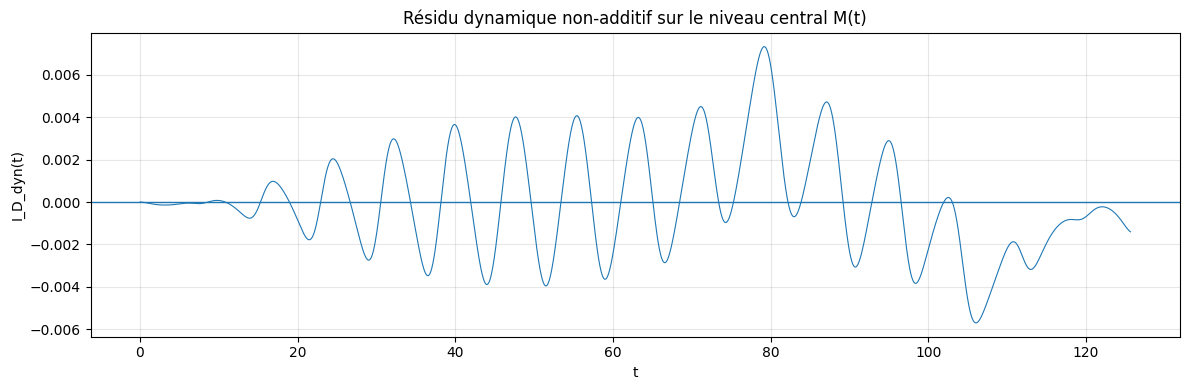

In [15]:
# ============================================================
# Résidu d'effet dynamique sur D_T du niveau central M(t)
# ============================================================

D_FULL = D_M["FULL"]
D_NL   = D_M["NO_LOWER"]
D_NU   = D_M["NO_UPPER"]
D_DEC  = D_M["DECOUPLED"]

I_D_dyn = D_FULL - D_NL - D_NU + D_DEC

print("Résidu dynamique I_D")
print("=" * 72)
print(f"mean     = {np.mean(I_D_dyn): .12e}")
print(f"std      = {np.std(I_D_dyn): .12e}")
print(f"min      = {np.min(I_D_dyn): .12e}")
print(f"max      = {np.max(I_D_dyn): .12e}")
print(f"abs_mean = {np.mean(np.abs(I_D_dyn)): .12e}")
print(f"rms      = {np.sqrt(np.mean(I_D_dyn**2)): .12e}")

effect_lower = D_NU - D_DEC      # effet du lien inférieur
effect_upper = D_NL - D_DEC      # effet du lien supérieur

print("\nRatios relatifs :")
print(
    "mean|I_D| / mean|D_NO_UPPER-D_DECOUPLED| = "
    f"{np.mean(np.abs(I_D_dyn)) / np.mean(np.abs(effect_lower)):.12f}"
)
print(
    "mean|I_D| / mean|D_NO_LOWER-D_DECOUPLED| = "
    f"{np.mean(np.abs(I_D_dyn)) / np.mean(np.abs(effect_upper)):.12f}"
)

plt.figure(figsize=(12, 4))
plt.plot(t_eval[1:], I_D_dyn, linewidth=0.8)
plt.axhline(0.0, linewidth=1.0)
plt.xlabel("t")
plt.ylabel("I_D_dyn(t)")
plt.title("Résidu dynamique non-additif sur le niveau central M(t)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Null dynamique par décalage circulaire des voisins L et U
# dans les termes de couplage vers M
# ============================================================

N_surr_dyn = 1000
seed_dyn = 20260708
rng_dyn = np.random.default_rng(seed_dyn)

I_obs_abs = np.mean(np.abs(I_D_dyn))
I_obs_rms = np.sqrt(np.mean(I_D_dyn**2))

null_dyn_abs = np.empty(N_surr_dyn)
null_dyn_rms = np.empty(N_surr_dyn)

theta_dec = phase_solutions["DECOUPLED"].y
theta_L_base = theta_dec[0]
theta_M_base = theta_dec[1]
theta_U_base = theta_dec[2]

for s in range(N_surr_dyn):

    shift_L = rng_dyn.integers(1, N)
    shift_U = rng_dyn.integers(1, N)

    theta_L_shift = np.roll(theta_L_base, shift_L)
    theta_U_shift = np.roll(theta_U_base, shift_U)

    # M null : reçoit des voisins désalignés temporellement
    dtheta_M_null = (
        omega_M
        + K_LM * np.sin(theta_L_shift - theta_M_base)
        + K_UM * np.sin(theta_U_shift - theta_M_base)
    )

    theta_M_null = theta_M_base[0] + np.cumsum(dtheta_M_null) * (t_eval[1] - t_eval[0])

    X_M_null = np.column_stack([
        np.cos(theta_M_null),
        np.sin(theta_M_null)
    ])

    D_null = compute_D_T(X_M_null)

    # Résidu null comparé aux mêmes ablations observées
    I_null = D_null - D_NL - D_NU + D_DEC

    null_dyn_abs[s] = np.mean(np.abs(I_null))
    null_dyn_rms[s] = np.sqrt(np.mean(I_null**2))


def summarize_null_dyn(label, values, obs):
    percentile = np.mean(values <= obs)
    p_upper = (1 + np.sum(values >= obs)) / (len(values) + 1)

    print(label)
    print("-" * 72)
    print(f"obs        = {obs:.12e}")
    print(f"mean null  = {np.mean(values):.12e}")
    print(f"median     = {np.median(values):.12e}")
    print(f"std        = {np.std(values, ddof=1):.12e}")
    print(f"Q2.5       = {np.percentile(values, 2.5):.12e}")
    print(f"Q97.5      = {np.percentile(values, 97.5):.12e}")
    print(f"percentile = {percentile:.6f}")
    print(f"p_upper    = {p_upper:.6f}")
    print()

print("Null dynamique — voisins L/U désalignés dans le couplage vers M")
print("=" * 72)

summarize_null_dyn(
    "Null dynamique — mean|I_D|",
    null_dyn_abs,
    I_obs_abs
)

summarize_null_dyn(
    "Null dynamique — RMS(I_D)",
    null_dyn_rms,
    I_obs_rms
)

Null dynamique — voisins L/U désalignés dans le couplage vers M
Null dynamique — mean|I_D|
------------------------------------------------------------------------
obs        = 1.902260224782e-03
mean null  = 2.281056651509e-03
median     = 2.307407854674e-03
std        = 3.589167584166e-04
Q2.5       = 1.655169436665e-03
Q97.5      = 2.794855764583e-03
percentile = 0.184000
p_upper    = 0.816184

Null dynamique — RMS(I_D)
------------------------------------------------------------------------
obs        = 2.462298088334e-03
mean null  = 2.797089068072e-03
median     = 2.806708245233e-03
std        = 4.239386279745e-04
Q2.5       = 2.092819424555e-03
Q97.5      = 3.425027788928e-03
percentile = 0.290000
p_upper    = 0.710290



In [17]:
# ============================================================
# Diagnostic direct de cohérence de phase
# Version robuste au runtime
#
# R_ab = | mean exp(i(theta_a - theta_b)) |
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Reconstruction de la liste des cas si nécessaire
# ------------------------------------------------------------

if "PHASE_CASES" not in globals():
    PHASE_CASES = (
        "FULL",
        "NO_LOWER",
        "NO_UPPER",
        "DECOUPLED",
    )
    print("PHASE_CASES reconstruit.\n")


# ------------------------------------------------------------
# 2. Vérification des solutions de phase
# ------------------------------------------------------------

if "phase_solutions" not in globals():
    raise RuntimeError(
        "phase_solutions est absente du runtime. "
        "Réexécute d'abord la cellule d'intégration "
        "du système phase-coupled."
    )

missing_cases = [
    case for case in PHASE_CASES
    if case not in phase_solutions
]

if missing_cases:
    raise RuntimeError(
        f"Cas absents de phase_solutions : {missing_cases}"
    )


# ------------------------------------------------------------
# 3. Fonction de cohérence résultante
# ------------------------------------------------------------

def phase_coherence(theta_a, theta_b):
    theta_a = np.asarray(theta_a, dtype=float)
    theta_b = np.asarray(theta_b, dtype=float)

    if theta_a.shape != theta_b.shape:
        raise ValueError(
            f"Shapes incompatibles : "
            f"{theta_a.shape} vs {theta_b.shape}"
        )

    return np.abs(
        np.mean(
            np.exp(
                1j * (theta_a - theta_b)
            )
        )
    )


# ------------------------------------------------------------
# 4. Calcul des cohérences
# ------------------------------------------------------------

phase_coh = {}

print("Cohérence directe de phase")
print("=" * 64)

print(
    "Cas        | R_LM         | R_MU         | R_LU"
)

print("-" * 64)

for case in PHASE_CASES:

    theta = np.asarray(
        phase_solutions[case].y,
        dtype=float
    )

    assert theta.shape[0] == 3, (
        f"Shape inattendue pour {case}: {theta.shape}"
    )

    theta_L = theta[0]
    theta_M = theta[1]
    theta_U = theta[2]

    R_LM = phase_coherence(theta_L, theta_M)
    R_MU = phase_coherence(theta_M, theta_U)
    R_LU = phase_coherence(theta_L, theta_U)

    phase_coh[case] = {
        "R_LM": R_LM,
        "R_MU": R_MU,
        "R_LU": R_LU,
    }

    print(
        f"{case:10s} | "
        f"{R_LM:.12f} | "
        f"{R_MU:.12f} | "
        f"{R_LU:.12f}"
    )


# ------------------------------------------------------------
# 5. Contrastes descriptifs pré-null
# ------------------------------------------------------------

print("\nContrastes descriptifs de R_LU")
print("=" * 64)

R_LU_FULL = phase_coh["FULL"]["R_LU"]

for case in (
    "NO_LOWER",
    "NO_UPPER",
    "DECOUPLED",
):
    delta = (
        R_LU_FULL
        - phase_coh[case]["R_LU"]
    )

    print(
        f"R_LU(FULL) - R_LU({case}) "
        f"= {delta:+.12e}"
    )

Cohérence directe de phase
Cas        | R_LM         | R_MU         | R_LU
----------------------------------------------------------------
FULL       | 0.107928698571 | 0.678741987058 | 0.032755917920
NO_LOWER   | 0.003118894895 | 0.657749611795 | 0.014941711100
NO_UPPER   | 0.115981720715 | 0.086553510587 | 0.007942616308
DECOUPLED  | 0.000200000000 | 0.089082298899 | 0.015662584266

Contrastes descriptifs de R_LU
R_LU(FULL) - R_LU(NO_LOWER) = +1.781420682078e-02
R_LU(FULL) - R_LU(NO_UPPER) = +2.481330161248e-02
R_LU(FULL) - R_LU(DECOUPLED) = +1.709333365402e-02


In [18]:
# ============================================================
# Diagnostic direct de cohérence de phase
# R_ab = | mean exp(i(theta_a - theta_b)) |
# ============================================================

def phase_coherence(theta_a, theta_b):
    return np.abs(
        np.mean(
            np.exp(1j * (theta_a - theta_b))
        )
    )

print("Cohérence directe de phase")
print("Cas        | R_LM       | R_MU       | R_LU")
print("-" * 60)

phase_coh = {}

for case in PHASE_CASES:
    theta = phase_solutions[case].y

    theta_L = theta[0]
    theta_M = theta[1]
    theta_U = theta[2]

    R_LM = phase_coherence(theta_L, theta_M)
    R_MU = phase_coherence(theta_M, theta_U)
    R_LU = phase_coherence(theta_L, theta_U)

    phase_coh[case] = {
        "R_LM": R_LM,
        "R_MU": R_MU,
        "R_LU": R_LU,
    }

    print(
        f"{case:10s} | "
        f"{R_LM:.9f} | "
        f"{R_MU:.9f} | "
        f"{R_LU:.9f}"
    )

Cohérence directe de phase
Cas        | R_LM       | R_MU       | R_LU
------------------------------------------------------------
FULL       | 0.107928699 | 0.678741987 | 0.032755918
NO_LOWER   | 0.003118895 | 0.657749612 | 0.014941711
NO_UPPER   | 0.115981721 | 0.086553511 | 0.007942616
DECOUPLED  | 0.000200000 | 0.089082299 | 0.015662584


In [19]:
# ============================================================
# Null génératif strict — phases initiales randomisées
# Réintégration complète du système FULL
# ============================================================

N_surr_gen = 1000
seed_gen = 20260708
rng_gen = np.random.default_rng(seed_gen)

R_LU_obs = phase_coh["FULL"]["R_LU"]

R_LM_null = np.empty(N_surr_gen)
R_MU_null = np.empty(N_surr_gen)
R_LU_null = np.empty(N_surr_gen)

for s in range(N_surr_gen):

    theta0_s = rng_gen.uniform(
        low=0.0,
        high=2.0 * np.pi,
        size=3
    )

    sol_s = solve_ivp(
        fun=lambda t, theta: phase_hierarchy_rhs(
            t=t,
            theta=theta,
            case="FULL"
        ),
        t_span=(t_min, t_max),
        y0=theta0_s,
        t_eval=t_eval,
        method=solver_method,
        rtol=rtol,
        atol=atol
    )

    assert sol_s.success
    assert sol_s.y.shape == (3, N)

    theta_L = sol_s.y[0]
    theta_M = sol_s.y[1]
    theta_U = sol_s.y[2]

    R_LM_null[s] = phase_coherence(theta_L, theta_M)
    R_MU_null[s] = phase_coherence(theta_M, theta_U)
    R_LU_null[s] = phase_coherence(theta_L, theta_U)


def summarize_phase_null(label, values, obs):
    percentile = np.mean(values <= obs)
    p_upper = (1 + np.sum(values >= obs)) / (len(values) + 1)

    print(label)
    print("-" * 72)
    print(f"obs        = {obs:.12f}")
    print(f"mean null  = {np.mean(values):.12f}")
    print(f"median     = {np.median(values):.12f}")
    print(f"std        = {np.std(values, ddof=1):.12f}")
    print(f"Q2.5       = {np.percentile(values, 2.5):.12f}")
    print(f"Q97.5      = {np.percentile(values, 97.5):.12f}")
    print(f"percentile = {percentile:.6f}")
    print(f"p_upper    = {p_upper:.6f}")
    print()


print("Null génératif strict — réintégration FULL avec phases initiales randomisées")
print("=" * 78)

summarize_phase_null(
    "R_LU — cohérence indirecte L-U",
    R_LU_null,
    R_LU_obs
)

summarize_phase_null(
    "R_LM — cohérence locale L-M",
    R_LM_null,
    phase_coh["FULL"]["R_LM"]
)

summarize_phase_null(
    "R_MU — cohérence locale M-U",
    R_MU_null,
    phase_coh["FULL"]["R_MU"]
)

Null génératif strict — réintégration FULL avec phases initiales randomisées
R_LU — cohérence indirecte L-U
------------------------------------------------------------------------
obs        = 0.032755917920
mean null  = 0.031984535742
median     = 0.033503683482
std        = 0.008259800288
Q2.5       = 0.012981013306
Q97.5      = 0.042543644018
percentile = 0.467000
p_upper    = 0.533467

R_LM — cohérence locale L-M
------------------------------------------------------------------------
obs        = 0.107928698571
mean null  = 0.096116396526
median     = 0.096207370159
std        = 0.010258417252
Q2.5       = 0.078383950581
Q97.5      = 0.114167006434
percentile = 0.842000
p_upper    = 0.158841

R_MU — cohérence locale M-U
------------------------------------------------------------------------
obs        = 0.678741987058
mean null  = 0.643800691842
median     = 0.649925267417
std        = 0.072609623765
Q2.5       = 0.525016121092
Q97.5      = 0.744911419032
percentile = 0.624000
p

In [20]:
# ============================================================
# Null génératif strict — GVH sur FULL uniquement
# Phases initiales randomisées + réintégration complète
# ============================================================

N_surr_gvh = 1000
seed_gvh = 20260708 + 2
rng_gvh = np.random.default_rng(seed_gvh)

# Observés FULL déjà calculés
D_std_obs_FULL = np.std(D_M["FULL"])
S_mean_obs_FULL = np.mean(S_M["FULL"])

D_std_FULL_null = np.empty(N_surr_gvh)
S_mean_FULL_null = np.empty(N_surr_gvh)

for s in range(N_surr_gvh):

    theta0_s = rng_gvh.uniform(
        low=0.0,
        high=2.0 * np.pi,
        size=3
    )

    sol_s = solve_ivp(
        fun=lambda t, theta: phase_hierarchy_rhs(
            t=t,
            theta=theta,
            case="FULL"
        ),
        t_span=(t_min, t_max),
        y0=theta0_s,
        t_eval=t_eval,
        method=solver_method,
        rtol=rtol,
        atol=atol
    )

    assert sol_s.success
    assert sol_s.y.shape == (3, N)

    theta_M = sol_s.y[1]

    X_M_s = np.column_stack([
        np.cos(theta_M),
        np.sin(theta_M)
    ])

    D_s = compute_D_T(X_M_s)
    S_s = compute_S_T(D_s)

    D_std_FULL_null[s] = np.std(D_s)
    S_mean_FULL_null[s] = np.mean(S_s)


def summarize_gvh_null(label, values, obs):
    percentile = np.mean(values <= obs)
    p_upper = (1 + np.sum(values >= obs)) / (len(values) + 1)

    print(label)
    print("-" * 72)
    print(f"obs        = {obs:.12e}")
    print(f"mean null  = {np.mean(values):.12e}")
    print(f"median     = {np.median(values):.12e}")
    print(f"std        = {np.std(values, ddof=1):.12e}")
    print(f"Q2.5       = {np.percentile(values, 2.5):.12e}")
    print(f"Q97.5      = {np.percentile(values, 97.5):.12e}")
    print(f"percentile = {percentile:.6f}")
    print(f"p_upper    = {p_upper:.6f}")
    print()


print("Null génératif strict — GVH sur FULL uniquement")
print("=" * 72)

summarize_gvh_null(
    "D_std FULL",
    D_std_FULL_null,
    D_std_obs_FULL
)

summarize_gvh_null(
    "S_mean FULL",
    S_mean_FULL_null,
    S_mean_obs_FULL
)

Null génératif strict — GVH sur FULL uniquement
D_std FULL
------------------------------------------------------------------------
obs        = 1.754569964396e-03
mean null  = 1.784691422127e-03
median     = 1.793934545236e-03
std        = 6.617537240827e-05
Q2.5       = 1.685064076073e-03
Q97.5      = 1.875462349347e-03
percentile = 0.383000
p_upper    = 0.617383

S_mean FULL
------------------------------------------------------------------------
obs        = 2.702295108457e-05
mean null  = 2.695595573265e-05
median     = 2.695126229556e-05
std        = 2.328405586746e-07
Q2.5       = 2.645712940938e-05
Q97.5      = 2.739062430757e-05
percentile = 0.604000
p_upper    = 0.396603



In [21]:
# ============================================================
# Null génératif strict — I_D complet apparié
# Même theta0_s pour FULL, NO_LOWER, NO_UPPER, DECOUPLED
# ============================================================

N_surr_ID = 1000
seed_ID = 20260708 + 3
rng_ID = np.random.default_rng(seed_ID)

I_obs_abs = np.mean(np.abs(I_D_dyn))
I_obs_rms = np.sqrt(np.mean(I_D_dyn**2))

I_null_abs = np.empty(N_surr_ID)
I_null_rms = np.empty(N_surr_ID)

def integrate_phase_case(theta0_s, case):
    sol = solve_ivp(
        fun=lambda t, theta: phase_hierarchy_rhs(t, theta, case=case),
        t_span=(t_min, t_max),
        y0=theta0_s,
        t_eval=t_eval,
        method=solver_method,
        rtol=rtol,
        atol=atol
    )
    assert sol.success
    theta_M = sol.y[1]
    X_M = np.column_stack([np.cos(theta_M), np.sin(theta_M)])
    return compute_D_T(X_M)

for s in range(N_surr_ID):

    theta0_s = rng_ID.uniform(0.0, 2.0 * np.pi, size=3)

    D_FULL_s = integrate_phase_case(theta0_s, "FULL")
    D_NL_s   = integrate_phase_case(theta0_s, "NO_LOWER")
    D_NU_s   = integrate_phase_case(theta0_s, "NO_UPPER")
    D_DEC_s  = integrate_phase_case(theta0_s, "DECOUPLED")

    I_s = D_FULL_s - D_NL_s - D_NU_s + D_DEC_s

    I_null_abs[s] = np.mean(np.abs(I_s))
    I_null_rms[s] = np.sqrt(np.mean(I_s**2))


def summarize_ID_null(label, values, obs):
    percentile = np.mean(values <= obs)
    p_upper = (1 + np.sum(values >= obs)) / (len(values) + 1)

    print(label)
    print("-" * 72)
    print(f"obs        = {obs:.12e}")
    print(f"mean null  = {np.mean(values):.12e}")
    print(f"median     = {np.median(values):.12e}")
    print(f"std        = {np.std(values, ddof=1):.12e}")
    print(f"Q2.5       = {np.percentile(values, 2.5):.12e}")
    print(f"Q97.5      = {np.percentile(values, 97.5):.12e}")
    print(f"percentile = {percentile:.6f}")
    print(f"p_upper    = {p_upper:.6f}")
    print()

print("Null génératif strict — I_D complet apparié")
print("=" * 72)

summarize_ID_null(
    "I_D mean|.|",
    I_null_abs,
    I_obs_abs
)

summarize_ID_null(
    "I_D RMS",
    I_null_rms,
    I_obs_rms
)

Null génératif strict — I_D complet apparié
I_D mean|.|
------------------------------------------------------------------------
obs        = 1.902260224782e-03
mean null  = 1.906655663669e-03
median     = 1.907349198838e-03
std        = 5.805113612996e-05
Q2.5       = 1.746479684818e-03
Q97.5      = 1.995345677569e-03
percentile = 0.446000
p_upper    = 0.554446

I_D RMS
------------------------------------------------------------------------
obs        = 2.462298088334e-03
mean null  = 2.456093731661e-03
median     = 2.467194238589e-03
std        = 7.537384269824e-05
Q2.5       = 2.200652939524e-03
Q97.5      = 2.560039778132e-03
percentile = 0.443000
p_upper    = 0.557443



## Conclusion générale — Benchmark tri-niveau et null génératif strict

Ce notebook a étudié la possibilité de détecter une organisation hiérarchique tri-niveau dans une architecture locale

\[
L \leftrightarrow M \leftrightarrow U,
\qquad
L \not\leftrightarrow U.
\]

L'analyse a progressé en plusieurs étapes méthodologiquement distinctes.

### 1. Hiérarchie additive

Un premier modèle fondé sur la superposition de trajectoires a produit un résidu apparent de non-additivité sur l'observable

\[
D_T = \|\Delta X\|.
\]

Les nulls circulaires ont montré que ce résidu n'était pas spécifique à l'organisation originale. Cette étape a mis en évidence un artefact structurel : une observable non linéaire peut produire une non-additivité apparente même lorsque les trajectoires sous-jacentes sont construites additivement.

### 2. Dynamique couplée diffusive

Le passage à une hiérarchie de dynamiques réellement couplées a d'abord été testé avec un couplage diffusif.

Ce générateur a été rejeté avant toute interprétation GVH en raison d'une forte contraction d'amplitude. Une analyse géométrique aurait alors principalement mesuré la dissipation induite par le modèle plutôt qu'une organisation hiérarchique spécifique.

### 3. Hiérarchie de phases couplées

Un système tri-niveau de type Kuramoto a ensuite été construit avec projection

\[
X_i(t)
=
\bigl(
\cos\theta_i(t),
\sin\theta_i(t)
\bigr),
\]

garantissant

\[
|X_i(t)| = 1.
\]

Les diagnostics de phase ont confirmé que les liens locaux actifs modifiaient effectivement la dynamique du niveau central \(M\).

Les observables géométriques calculées sur \(M(t)\) ont montré de fortes modifications descriptives entre les cas

\[
FULL,\quad
NO\_LOWER,\quad
NO\_UPPER,\quad
DECOUPLED.
\]

Un résidu dynamique

\[
I_D
=
D_{FULL}
-
D_{NO\_LOWER}
-
D_{NO\_UPPER}
+
D_{DECOUPLED}
\]

a également présenté une magnitude importante.

### 4. Null génératif strict

Afin de distinguer une signature spécifique d'une propriété typique du régime dynamique, un null génératif strict a été construit.

Pour chaque surrogate :

1. les phases initiales ont été randomisées ;
2. les équations différentielles ont été entièrement réintégrées ;
3. les paramètres intrinsèques et les constantes de couplage ont été conservés ;
4. pour le test final de \(I_D\), le même vecteur initial

\[
\theta_0^{(s)}
\]

a été utilisé pour les quatre branches

\[
FULL,\quad
NO\_LOWER,\quad
NO\_UPPER,\quad
DECOUPLED.
\]

Les percentiles empiriques décisifs sont :

\[
R_{LU} : 0.467,
\]

\[
D_{\rm std}^{FULL} : 0.383,
\]

\[
S_{\rm mean}^{FULL} : 0.604,
\]

\[
\operatorname{mean}|I_D| : 0.446,
\]

\[
RMS(I_D) : 0.443.
\]

### Verdict

Les statistiques observées restent non exceptionnelles sous le null génératif strict.

Ainsi, dans le régime Kuramoto tri-niveau étudié, les fortes modifications géométriques du niveau central et la grande magnitude du résidu \(I_D\) sont des propriétés typiques de l'architecture dynamique considérée sous variation des conditions initiales.

Elles ne constituent pas une signature spécifique d'une organisation hiérarchique privilégiée de la réalisation observée.

Ce résultat ne démontre ni que GVH est invalide, ni que toute hiérarchie dynamique est indétectable. Il établit plus précisément que ce benchmark ne fournit pas un phénomène positif identifiable face à son null génératif strict.

Le système Kuramoto tri-niveau étudié est donc archivé comme :

\[
\boxed{
\text{benchmark négatif validé}
}
\]

### Jalon suivant

Le prochain volet du programme devra être séparé de ce benchmark et préspécifié avant simulation :

\[
\boxed{
\text{Construire un benchmark positif contrôlé}
\rightarrow
\text{démontrer directement le phénomène}
\rightarrow
\text{figer les règles de décision}
\rightarrow
\text{tester ensuite GVH sans calibration post hoc}
}
\]

Le présent notebook est clos à ce stade.
